In [1]:
!git clone https://github.com/Break-Through-Tech/Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery.git
%cd Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery

Cloning into 'Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 36 (delta 16), reused 20 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 14.52 KiB | 4.84 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery


In [2]:
!ls -la

total 60
drwxr-xr-x 5 root root 4096 Sep 23 18:26 .
drwxr-xr-x 1 root root 4096 Sep 23 18:26 ..
-rw-r--r-- 1 root root 8437 Sep 23 18:26 Challenge-Project-Overview.md
drwxr-xr-x 2 root root 4096 Sep 23 18:26 data
-rw-r--r-- 1 root root 1072 Sep 23 18:26 download_tiles.py
-rw-r--r-- 1 root root  637 Sep 23 18:26 getcollection.py
-rw-r--r-- 1 root root 1798 Sep 23 18:26 Getting-Started-for-Fellows.md
drwxr-xr-x 8 root root 4096 Sep 23 18:26 .git
-rw-r--r-- 1 root root  140 Sep 23 18:26 .gitignore
drwxr-xr-x 2 root root 4096 Sep 23 18:26 notebooks
-rw-r--r-- 1 root root 4319 Sep 23 18:26 README.md
-rw-r--r-- 1 root root    1 Sep 23 18:26 requirements.txt


Install libraries

In [3]:
!pip -q install \
    rasterio \
    leafmap \
    pystac-client \
    fsspec \
    rio-tiler \
    geopandas \
    shapely \
    scikit-image \
    scipy \
    transformers \
    scikit-learn \
    matplotlib \
    lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.8/316.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 593.1/593.1 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/8

Checking if the environment is working fine

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
import torch
from pystac_client import Client

print("Working directory:", os.getcwd())
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Setup successful!")

Working directory: /content/Ursa-Space-Systems-1D-cloud-detection-in-very-high-resolution-optical-satellite-imagery
PyTorch version: 2.11.0+cpu
GPU available: False
Setup successful!


Mount the directory to your google drive

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Week 2: Satellite Data Preprocessing & HSV Cloud Detection

## 1. Environment & Drive Setup
Mount Google Drive and load required geospatial dependencies (`rasterio`, `numpy`, `matplotlib`).

## 2. NoData Border Filtering & Cropping
Locate valid pixel regions to filter out large black border regions from the satellite tile swath.

## 3. Percentile Winsorization (Contrast Scaling)
Apply 2nd and 98th percentile intensity clipping to standardize RGB channels across valid imagery pixels.

## 4. HSV Surface & Cloud Disambiguation
Convert RGB to HSV color space to isolate neutral white clouds from bright ground surfaces like sand, concrete, and rooftops.

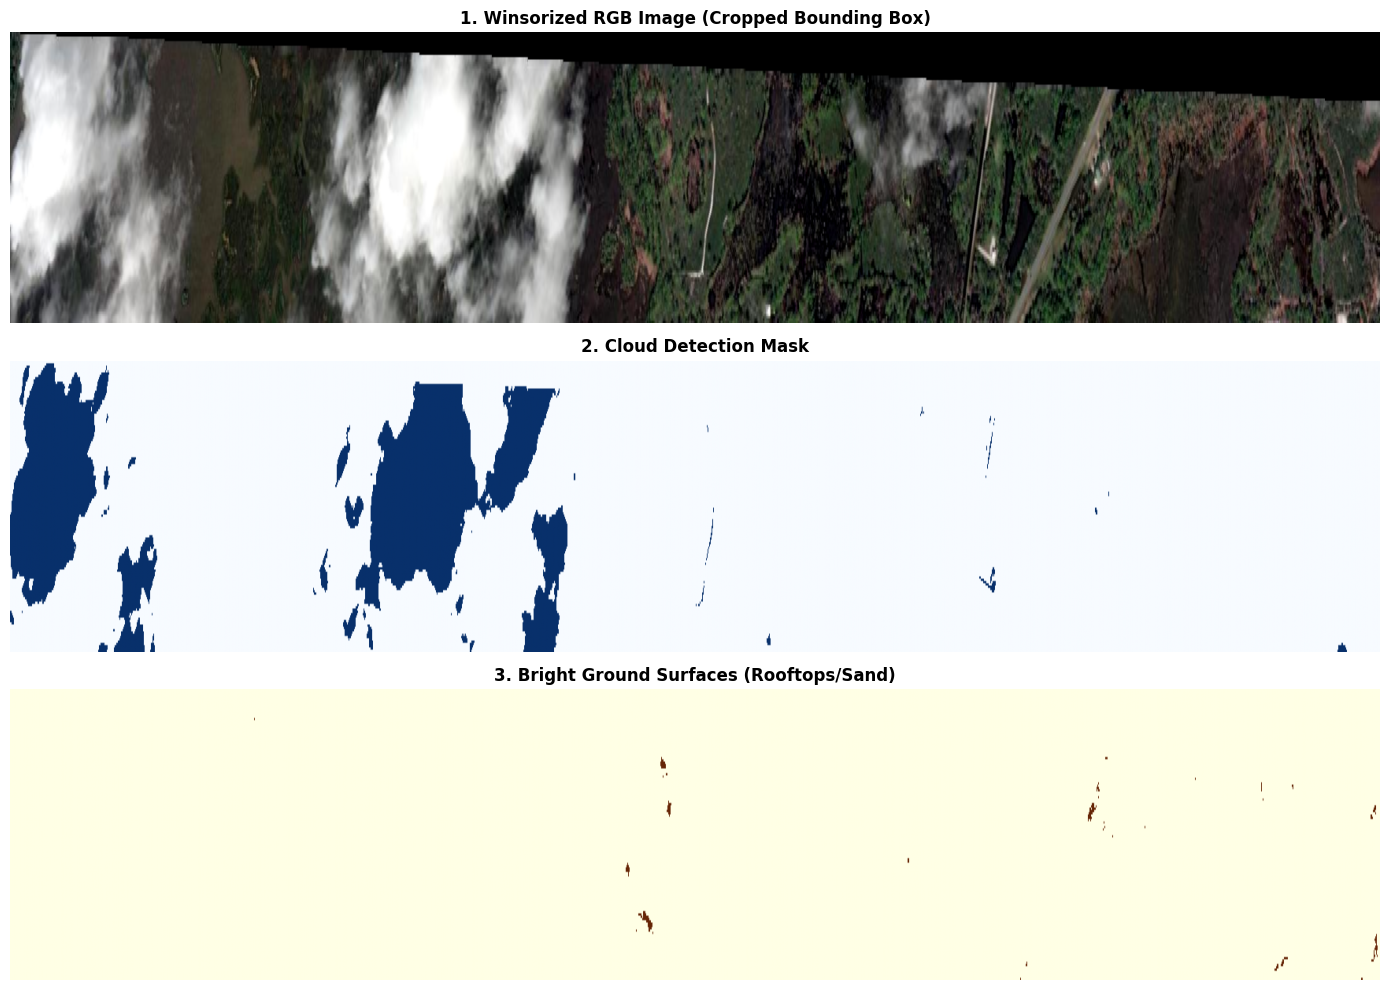

In [4]:
import os
import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv

# this is google drive folder path to satellite tile
image_path = "/content/drive/MyDrive/HurricaneHeleneOct24Data/1030010105AA2600/031313233002/1030010105AA2600-visual.tif"

with rasterio.open(image_path) as src:
    scale = 0.1
    out_height = int(src.height * scale)
    out_width = int(src.width * scale)
    num_bands = min(src.count, 3)

    # Read downsampled imagery
    raw_data = src.read(
        list(range(1, num_bands + 1)),
        out_shape=(num_bands, out_height, out_width),
        resampling=Resampling.bilinear
    )

# code to reshape to (Height, Width, Channels)
image_rgb = np.moveaxis(raw_data, 0, -1) if num_bands == 3 else np.repeat(raw_data[0][..., None], 3, axis=-1)

#1. code for "FILTER NODATA & CROP TO VALID SATELLITE STRIP"
valid_mask = np.any(image_rgb > 0, axis=-1)

# To find bounding box of valid data pixels
valid_rows, valid_cols = np.where(valid_mask)
row_min, row_max = valid_rows.min(), valid_rows.max()
col_min, col_max = valid_cols.min(), valid_cols.max()

# Crop both the RGB image and mask strictly to the valid region
cropped_rgb = image_rgb[row_min:row_max+1, col_min:col_max+1]
cropped_mask = valid_mask[row_min:row_max+1, col_min:col_max+1]

# Normalize raw pixel intensities to [0.0, 1.0]
norm_rgb = cropped_rgb.astype(np.float32) / (255.0 if cropped_rgb.max() > 1.0 else 1.0)

# 2. PERCENTILE WINSORIZATION (2nd to 98th Percentile)
winsorized_rgb = norm_rgb.copy()

for c in range(3):
    valid_p = norm_rgb[cropped_mask, c]
    if len(valid_p) > 0:
        p_low, p_high = np.percentile(valid_p, (2, 98))
        winsorized_rgb[..., c] = np.clip(norm_rgb[..., c], p_low, p_high)
        denom = p_high - p_low if p_high > p_low else 1e-8
        winsorized_rgb[..., c] = (winsorized_rgb[..., c] - p_low) / denom

# Set internal null pixels to black
winsorized_rgb[~cropped_mask] = 0
winsorized_rgb = np.clip(winsorized_rgb, 0, 1)

# 3. HSV CLOUD VS BRIGHT SURFACE DISAMBIGUATION
hsv = rgb_to_hsv(winsorized_rgb)
brightness = hsv[..., 2]
saturation = hsv[..., 1]

# Clouds: High brightness, low saturation
cloud_mask = (brightness > 0.70) & (saturation < 0.20) & cropped_mask

# Bright Ground: High brightness with color tint (sand, roofs, concrete)
bright_ground_mask = (brightness > 0.50) & (saturation >= 0.20) & cropped_mask

# VISUALIZATION WITH CONTROLLED ASPECT RATIO
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].imshow(winsorized_rgb, aspect='auto')
axes[0].set_title("1. Winsorized RGB Image (Cropped Bounding Box)", fontsize=12, fontweight='bold')

axes[1].imshow(cloud_mask, cmap="Blues", aspect='auto')
axes[1].set_title("2. Cloud Detection Mask", fontsize=12, fontweight='bold')

axes[2].imshow(bright_ground_mask, cmap="YlOrBr", aspect='auto')
axes[2].set_title("3. Bright Ground Surfaces (Rooftops/Sand)", fontsize=12, fontweight='bold')

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()